# Derivative-Based Event Detection

Simple approach: smooth the signal, compute the derivative, threshold it to find where the signal shifts (event onset/offset). No ML needed — just calculus.

In [123]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "requests", "numpy", "pandas", "scipy", "matplotlib"])


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


0

In [124]:
import requests
import numpy as np
import pandas as pd
from datetime import datetime, timezone, timedelta
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

HASURA_URL = "https://hasura.pipestuesday.org/v1/graphql"
HASURA_ADMIN_SECRET = "PIPE_SUPERMMMSECRET_PIPE"
HEADERS = {
    "Content-Type": "application/json",
    "x-hasura-admin-secret": HASURA_ADMIN_SECRET,
}

def gql_query(query: str, variables: dict = None) -> dict:
    payload = {"query": query}
    if variables:
        payload["variables"] = variables
    resp = requests.post(HASURA_URL, json=payload, headers=HEADERS)
    resp.raise_for_status()
    body = resp.json()
    if "errors" in body:
        raise RuntimeError(f"GraphQL errors: {body['errors']}")
    return body["data"]

print("Ready")

Ready


## 1. Fetch Data

In [125]:
SENSOR_ID = 6

# Fixed time window: 4:30pm - 5:00pm Eastern today (UTC-4)
from zoneinfo import ZoneInfo
eastern = ZoneInfo("America/New_York")
start_time = datetime(2026, 3, 29, 16, 30, tzinfo=eastern)
end_time = datetime(2026, 3, 29, 17, 0, tzinfo=eastern)

reports = gql_query("""
query GetMag($sensor_id: bigint!, $since: timestamptz!, $until: timestamptz!) {
  mag_report(
    where: { sensor_id: {_eq: $sensor_id}, created_at: {_gte: $since, _lte: $until} }
    order_by: {created_at: asc}
    limit: 100000
  ) { created_at, x_axis_reading }
}
""", variables={"sensor_id": str(SENSOR_ID),
                "since": start_time.isoformat(),
                "until": end_time.isoformat()})["mag_report"]

print(f"Sensor {SENSOR_ID}: {len(reports)} readings from 4:30pm-5:00pm ET")

df = pd.DataFrame(reports)
df["created_at"] = pd.to_datetime(df["created_at"], format="ISO8601")
df["x"] = pd.to_numeric(df["x_axis_reading"], errors="coerce")
df = df.dropna(subset=["x"]).reset_index(drop=True)

# Remove outliers: drop points more than 3 std from median
med = df["x"].median()
std = df["x"].std()
outlier_mask = (df["x"] - med).abs() > 3 * std
n_outliers = outlier_mask.sum()
df = df[~outlier_mask].reset_index(drop=True)
print(f"Removed {n_outliers} outlier(s) (>3\u03c3 from median)")

print(f"Time range: {df['created_at'].min()} -> {df['created_at'].max()}")

Sensor 6: 17838 readings from 4:30pm-5:00pm ET
Removed 20 outlier(s) (>3σ from median)
Time range: 2026-03-29 20:30:00.084000+00:00 -> 2026-03-29 20:59:59.996000+00:00


## 2. Fetch Calibration Labels (Ground Truth)

Pull labeled events for this sensor from the DB to learn thresholds from real data.

In [126]:
# Fetch ALL calibration labels (same as DTW notebook), then filter to our sensor
data = gql_query("""
query {
  calibration_label(order_by: {created_at: asc}) {
    id
    start_time
    end_time
    fixture {
      id
      name
      type
      sensor_id
    }
  }
}
""")

labels_raw = data["calibration_label"]
print(f"Total calibration labels: {len(labels_raw)}")

rows = []
for lab in labels_raw:
    fixture = lab.get("fixture") or {}
    rows.append({
        "label_id": lab["id"],
        "start_time": lab["start_time"],
        "end_time": lab["end_time"],
        "fixture_id": fixture.get("id"),
        "fixture_name": fixture.get("name"),
        "fixture_type": fixture.get("type"),
        "sensor_id": fixture.get("sensor_id"),
    })

df_all_labels = pd.DataFrame(rows)
df_all_labels["start_time"] = pd.to_datetime(df_all_labels["start_time"], format="ISO8601")
df_all_labels["end_time"] = pd.to_datetime(df_all_labels["end_time"], format="ISO8601")
df_all_labels["duration_s"] = (df_all_labels["end_time"] - df_all_labels["start_time"]).dt.total_seconds()

# Filter to our sensor
df_sensor_labels = df_all_labels[df_all_labels["sensor_id"] == SENSOR_ID].reset_index(drop=True)
print(f"Labels for sensor {SENSOR_ID}: {len(df_sensor_labels)}")

if len(df_sensor_labels) > 0:
    print(f"\n--- Labels by fixture type ---")
    print(df_sensor_labels["fixture_type"].value_counts().to_string())
    print(f"\n--- Duration stats (seconds) ---")
    print(df_sensor_labels.groupby("fixture_type")["duration_s"].describe().round(1).to_string())

df_sensor_labels.head(10)

Total calibration labels: 14
Labels for sensor 6: 14

--- Labels by fixture type ---
fixture_type
toilet    10
sink       4

--- Duration stats (seconds) ---
              count  mean  std   min   25%   50%   75%   max
fixture_type                                                
sink            4.0  16.3  1.4  15.0  15.3  16.0  16.9  18.3
toilet         10.0  25.0  0.0  25.0  25.0  25.0  25.0  25.0


,label_id,start_time,end_time,fixture_id,fixture_name,fixture_type,sensor_id,duration_s
0,22,2026-03-28 17:17:17.764000+00:00,2026-03-28 17:17:42.764000+00:00,50,men left toilet,toilet,6,25.000
1,24,2026-03-28 17:20:53.225000+00:00,2026-03-28 17:21:18.225000+00:00,49,men right toilet,toilet,6,25.000
2,26,2026-03-28 17:25:53.650000+00:00,2026-03-28 17:26:18.650000+00:00,53,women right toilet,toilet,6,25.000
3,27,2026-03-28 17:28:14.287000+00:00,2026-03-28 17:28:32.538000+00:00,51,men sink,sink,6,18.251
4,28,2026-03-28 17:29:12.351000+00:00,2026-03-28 17:29:27.781000+00:00,54,women sink,sink,6,15.430
5,29,2026-03-28 17:30:22.813000+00:00,2026-03-28 17:30:37.813000+00:00,51,men sink,sink,6,15.000
6,30,2026-03-28 17:31:21.275000+00:00,2026-03-28 17:31:37.773000+00:00,54,women sink,sink,6,16.498
7,31,2026-03-28 17:34:46.304000+00:00,2026-03-28 17:35:11.304000+00:00,49,men right toilet,toilet,6,25.000
8,32,2026-03-28 17:36:46.870000+00:00,2026-03-28 17:37:11.870000+00:00,52,women left toilet,toilet,6,25.000
9,34,2026-03-28 17:43:47.960000+00:00,2026-03-28 17:44:12.960000+00:00,53,women right toilet,toilet,6,25.000


## 3. Fetch Mag Data for Each Label + Learn Thresholds

For each labeled event, fetch the x-axis signal and measure what the derivative and deviation look like at known event onsets. Use these stats to set thresholds automatically.

In [127]:
# For each label, fetch mag data with some padding before/after to capture the onset edge
PADDING_S = 5  # seconds of context before and after the label

segments = []
for _, row in df_sensor_labels.iterrows():
    t0 = (row["start_time"] - timedelta(seconds=PADDING_S)).isoformat()
    t1 = (row["end_time"] + timedelta(seconds=PADDING_S)).isoformat()

    mag = gql_query("""
    query GetMag($sensor_id: bigint!, $since: timestamptz!, $until: timestamptz!) {
      mag_report(
        where: { sensor_id: {_eq: $sensor_id}, created_at: {_gte: $since, _lte: $until} }
        order_by: {created_at: asc}
        limit: 100000
      ) { created_at, x_axis_reading }
    }
    """, variables={"sensor_id": str(SENSOR_ID), "since": t0, "until": t1})["mag_report"]

    if len(mag) == 0:
        print(f"  WARNING: label {row['label_id']} — 0 readings")
        continue

    df_seg = pd.DataFrame(mag)
    df_seg["created_at"] = pd.to_datetime(df_seg["created_at"], format="ISO8601")
    df_seg["x"] = pd.to_numeric(df_seg["x_axis_reading"], errors="coerce")
    df_seg = df_seg.dropna(subset=["x"])

    segments.append({
        "label_id": row["label_id"],
        "fixture_type": row["fixture_type"],
        "fixture_name": row["fixture_name"],
        "label_start": row["start_time"],
        "label_end": row["end_time"],
        "df": df_seg,
    })

print(f"Loaded {len(segments)} labeled segments with mag data")

Loaded 14 labeled segments with mag data


### Visualize Calibration Segments

See what the labeled events actually look like — the quiet baseline (gray) vs the active event (colored). This is what we're teaching the detector to find.

/var/folders/m5/56bf4mwd3wn96np9dzczw3xr0000gn/T/ipykernel_14009/3894715086.py:13: UserWarning: no explicit representation of timezones available for np.datetime64
  onset_idx = np.argmin(np.abs(t - np.datetime64(seg["label_start"])))
/var/folders/m5/56bf4mwd3wn96np9dzczw3xr0000gn/T/ipykernel_14009/3894715086.py:14: UserWarning: no explicit representation of timezones available for np.datetime64
  end_idx = np.argmin(np.abs(t - np.datetime64(seg["label_end"])))


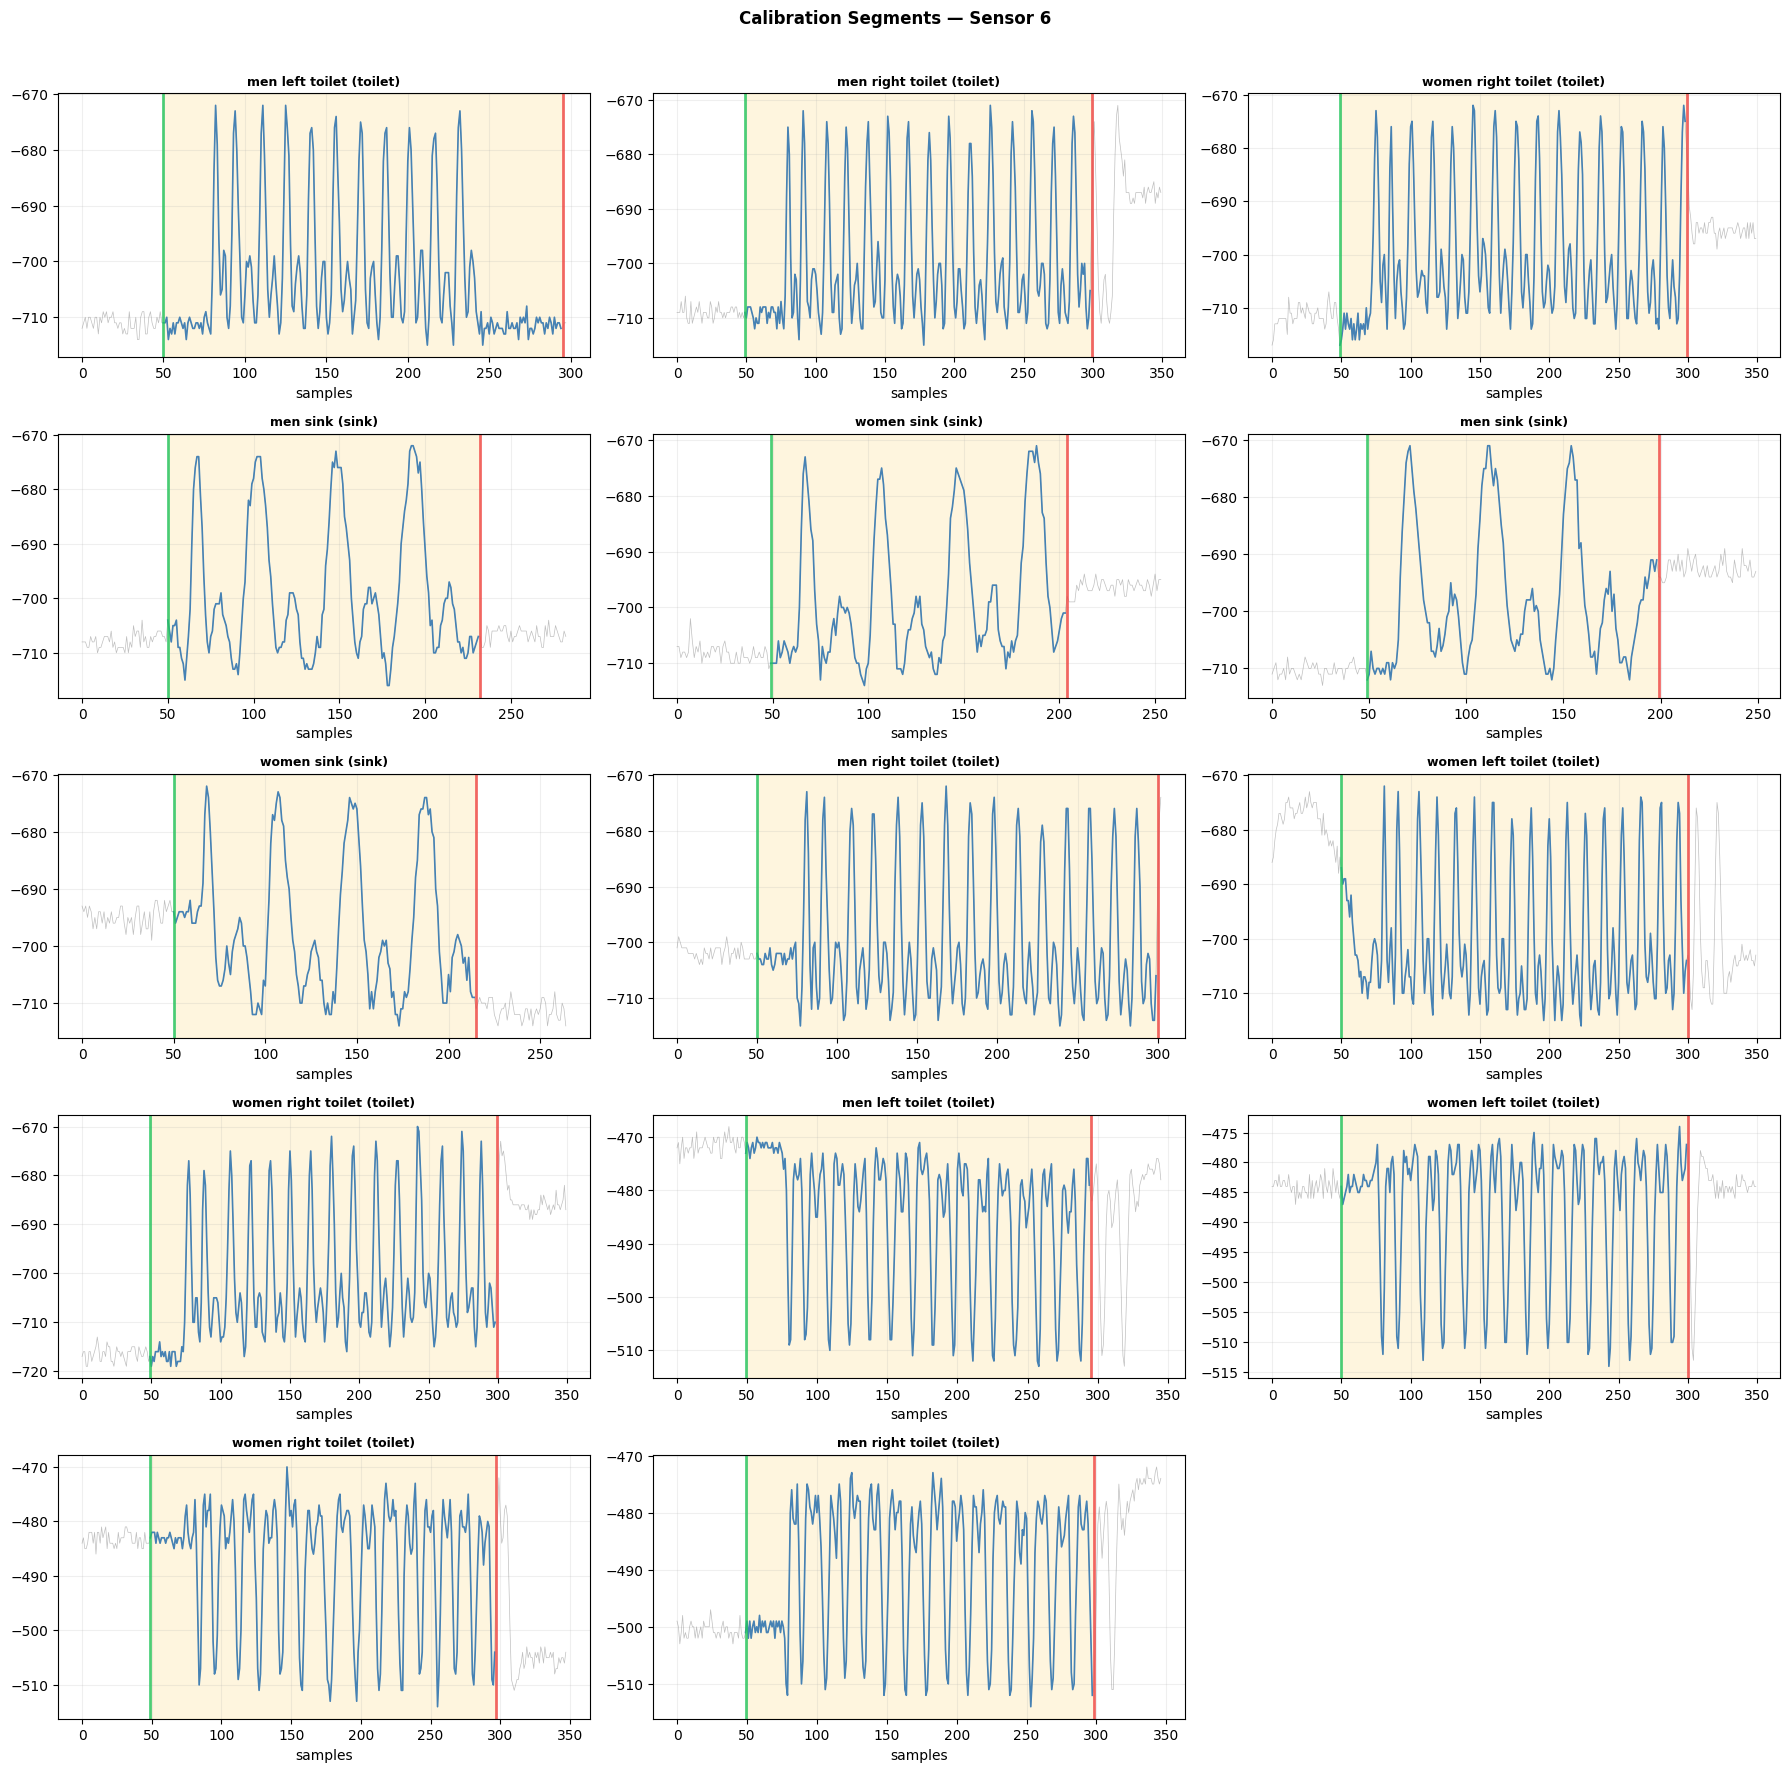

In [128]:
n_seg = len(segments)
cols = min(3, n_seg)
rows = (n_seg + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.5 * rows), squeeze=False)

for i, seg in enumerate(segments):
    ax = axes[i // cols, i % cols]
    d = seg["df"]
    x = d["x"].values.astype(float)
    t = d["created_at"].values
    
    # Color by quiet (before/after label) vs active (within label)
    onset_idx = np.argmin(np.abs(t - np.datetime64(seg["label_start"])))
    end_idx = np.argmin(np.abs(t - np.datetime64(seg["label_end"])))
    
    ax.plot(range(len(x)), x, lw=0.5, color="gray", alpha=0.5)
    ax.plot(range(onset_idx, end_idx), x[onset_idx:end_idx], lw=1.2, color="steelblue")
    ax.axvline(onset_idx, color="#22c55e", lw=2, ls="-", alpha=0.8)
    ax.axvline(end_idx, color="#ef4444", lw=2, ls="-", alpha=0.8)
    ax.axvspan(onset_idx, end_idx, color="#fbbf24", alpha=0.15)
    
    name = seg["fixture_name"] or f"label_{seg['label_id']}"
    ax.set_title(f"{name} ({seg['fixture_type']})", fontsize=9, fontweight="bold")
    ax.set_xlabel("samples")
    ax.grid(True, alpha=0.2)

for i in range(n_seg, rows * cols):
    axes[i // cols, i % cols].set_visible(False)

plt.suptitle(f"Calibration Segments — Sensor {SENSOR_ID}", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [129]:
# --- TUNABLES ---
SMOOTH_WINDOW = 31          # savgol smoothing (odd, samples)
SMOOTH_POLY = 2
BASELINE_WINDOW = 501       # rolling median window for baseline (odd, long = slow-moving)
MIN_EVENT_GAP = 100         # merge events closer than this (samples)
MIN_EVENT_LEN = 25          # drop events shorter than this (samples)
# ----------------

# Collect stats from labeled data: what does quiet look like vs what does active look like
quiet_values = []       # raw signal values during quiet
active_values = []      # raw signal values during events
quiet_derivs = []       # |derivative| during quiet
active_derivs = []      # |derivative| during events
quiet_stds = []         # rolling std during quiet
active_stds = []        # rolling std during events

ROLLING_STD_WIN = 15    # window for rolling std feature

for seg in segments:
    d = seg["df"]
    x = d["x"].values.astype(float)
    t = d["created_at"].values

    if len(x) < 20:
        continue

    sm = savgol_filter(x, window_length=min(SMOOTH_WINDOW, len(x) // 2 * 2 + 1), polyorder=SMOOTH_POLY)
    dr = np.abs(np.diff(sm))
    roll_std = pd.Series(x).rolling(ROLLING_STD_WIN, center=True, min_periods=3).std().values

    onset_idx = np.argmin(np.abs(t - np.datetime64(seg["label_start"])))
    end_idx = np.argmin(np.abs(t - np.datetime64(seg["label_end"])))

    # Quiet = before onset (padding region)
    if onset_idx > 3:
        quiet_values.extend(sm[:onset_idx].tolist())
        quiet_derivs.extend(dr[:max(onset_idx-1, 0)].tolist())
        quiet_stds.extend(roll_std[:onset_idx][~np.isnan(roll_std[:onset_idx])].tolist())

    # Active = within labeled event
    if end_idx > onset_idx:
        active_values.extend(sm[onset_idx:end_idx].tolist())
        active_derivs.extend(dr[onset_idx:min(end_idx, len(dr))].tolist())
        active_stds.extend(roll_std[onset_idx:end_idx][~np.isnan(roll_std[onset_idx:end_idx])].tolist())

quiet_values = np.array(quiet_values)
active_values = np.array(active_values)
quiet_derivs = np.array(quiet_derivs)
active_derivs = np.array(active_derivs)
quiet_stds = np.array(quiet_stds)
active_stds = np.array(active_stds)

print("=== Quiet vs Active comparison ===")
print(f"  Quiet:  n={len(quiet_values)}, mean={quiet_values.mean():.1f}, std={quiet_values.std():.2f}")
print(f"  Active: n={len(active_values)}, mean={active_values.mean():.1f}, std={active_values.std():.2f}")
print(f"\n  Quiet  |deriv|: mean={quiet_derivs.mean():.4f}, p95={np.percentile(quiet_derivs, 95):.4f}, p99={np.percentile(quiet_derivs, 99):.4f}")
print(f"  Active |deriv|: mean={active_derivs.mean():.4f}, p25={np.percentile(active_derivs, 25):.4f}, median={np.median(active_derivs):.4f}")
print(f"\n  Quiet  rolling_std: mean={quiet_stds.mean():.4f}, p95={np.percentile(quiet_stds, 95):.4f}, p99={np.percentile(quiet_stds, 99):.4f}")
print(f"  Active rolling_std: mean={active_stds.mean():.4f}, p25={np.percentile(active_stds, 25):.4f}, median={np.median(active_stds):.4f}")

# Learned thresholds: set between quiet p99 and active p25 (the gap between noise ceiling and weakest event floor)
learned_deriv_thresh = (np.percentile(quiet_derivs, 99) + np.percentile(active_derivs, 25)) / 2
learned_std_thresh = (np.percentile(quiet_stds, 99) + np.percentile(active_stds, 25)) / 2

print(f"\n=== Learned thresholds ===")
print(f"  |derivative|: {learned_deriv_thresh:.4f}  (between quiet p99={np.percentile(quiet_derivs, 99):.4f} and active p25={np.percentile(active_derivs, 25):.4f})")
print(f"  rolling_std:  {learned_std_thresh:.4f}  (between quiet p99={np.percentile(quiet_stds, 99):.4f} and active p25={np.percentile(active_stds, 25):.4f})")

=== Quiet vs Active comparison ===
  Quiet:  n=692, mean=-642.3, std=99.86
  Active: n=3140, mean=-632.8, std=98.84

  Quiet  |deriv|: mean=0.1118, p95=0.3649, p99=0.6683
  Active |deriv|: mean=0.8350, p25=0.2424, median=0.7034

  Quiet  rolling_std: mean=1.4326, p95=2.3157, p99=3.5064
  Active rolling_std: mean=10.6370, p25=10.8395, median=12.2630

=== Learned thresholds ===
  |derivative|: 0.4554  (between quiet p99=0.6683 and active p25=0.2424)
  rolling_std:  7.1730  (between quiet p99=3.5064 and active p25=10.8395)


/var/folders/m5/56bf4mwd3wn96np9dzczw3xr0000gn/T/ipykernel_14009/3250840667.py:31: UserWarning: no explicit representation of timezones available for np.datetime64
  onset_idx = np.argmin(np.abs(t - np.datetime64(seg["label_start"])))
/var/folders/m5/56bf4mwd3wn96np9dzczw3xr0000gn/T/ipykernel_14009/3250840667.py:32: UserWarning: no explicit representation of timezones available for np.datetime64
  end_idx = np.argmin(np.abs(t - np.datetime64(seg["label_end"])))


## 4. Visualize Learned Thresholds vs Event Onsets

Show the distribution of derivative/deviation at known onsets vs quiet periods, with the learned thresholds overlaid.

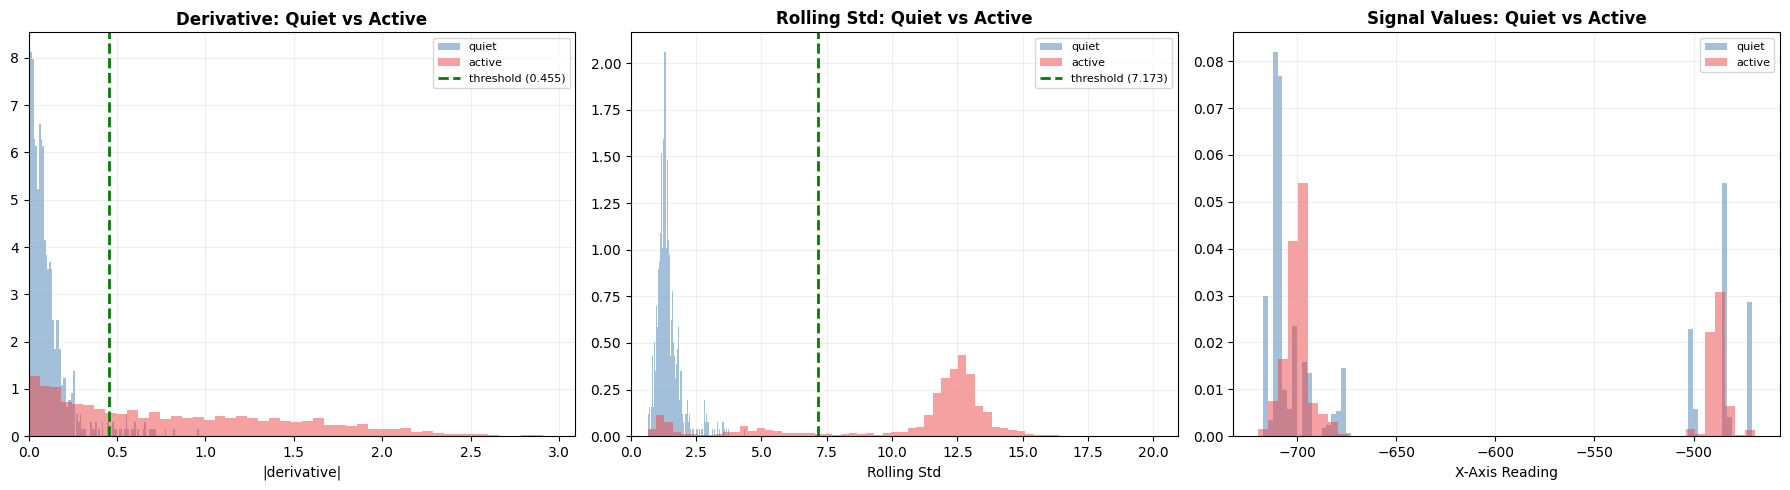

In [130]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Derivative distributions
ax1.hist(quiet_derivs, bins=100, alpha=0.5, color="steelblue", label="quiet", density=True)
ax1.hist(active_derivs, bins=50, alpha=0.5, color="#ef4444", label="active", density=True)
ax1.axvline(learned_deriv_thresh, color="green", lw=2, ls="--", label=f"threshold ({learned_deriv_thresh:.3f})")
ax1.set_xlabel("|derivative|")
ax1.set_title("Derivative: Quiet vs Active", fontweight="bold")
ax1.legend(fontsize=8)
ax1.set_xlim(0, np.percentile(active_derivs, 95) * 1.5)
ax1.grid(True, alpha=0.2)

# Rolling std distributions
ax2.hist(quiet_stds, bins=100, alpha=0.5, color="steelblue", label="quiet", density=True)
ax2.hist(active_stds, bins=50, alpha=0.5, color="#ef4444", label="active", density=True)
ax2.axvline(learned_std_thresh, color="green", lw=2, ls="--", label=f"threshold ({learned_std_thresh:.3f})")
ax2.set_xlabel("Rolling Std")
ax2.set_title("Rolling Std: Quiet vs Active", fontweight="bold")
ax2.legend(fontsize=8)
ax2.set_xlim(0, np.percentile(active_stds, 95) * 1.5)
ax2.grid(True, alpha=0.2)

# Signal value distributions
ax3.hist(quiet_values, bins=100, alpha=0.5, color="steelblue", label="quiet", density=True)
ax3.hist(active_values, bins=50, alpha=0.5, color="#ef4444", label="active", density=True)
ax3.set_xlabel("X-Axis Reading")
ax3.set_title("Signal Values: Quiet vs Active", fontweight="bold")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 5. Run Detection on Live Stream + Visualize

In [131]:
# Process the 15min stream signal
raw = df["x"].values.astype(float)
ts = df["created_at"].values

smooth = savgol_filter(raw, window_length=SMOOTH_WINDOW, polyorder=SMOOTH_POLY)
baseline = pd.Series(smooth).rolling(BASELINE_WINDOW, center=True, min_periods=1).median().values
deviation = np.abs(smooth - baseline)
deriv = np.abs(np.diff(smooth))
roll_std = pd.Series(raw).rolling(ROLLING_STD_WIN, center=True, min_periods=3).std().fillna(0).values

# Detection: a timestamp is "in event" if EITHER:
#   - rolling std exceeds threshold (signal is volatile)
#   - |derivative| exceeds threshold AND deviation from baseline is above median quiet deviation
is_volatile = roll_std > learned_std_thresh
is_edge = np.zeros(len(smooth), dtype=bool)
is_edge[1:] = deriv > learned_deriv_thresh

# Build event mask
is_event = np.zeros(len(smooth), dtype=bool)
in_event = False
for i in range(len(smooth)):
    if not in_event:
        # Enter event: need both volatility AND a derivative edge nearby
        if is_volatile[i] and np.any(is_edge[max(0, i-5):min(len(is_edge), i+5)]):
            in_event = True
            is_event[i] = True
    else:
        # Stay in event while volatile
        if is_volatile[i]:
            is_event[i] = True
        else:
            in_event = False

# Extract + merge events
raw_events = []
in_ev = False
for i in range(len(is_event)):
    if is_event[i] and not in_ev:
        ev_start = i
        in_ev = True
    elif not is_event[i] and in_ev:
        raw_events.append((ev_start, i - 1))
        in_ev = False
if in_ev:
    raw_events.append((ev_start, len(is_event) - 1))

events_l = []
for s, e in raw_events:
    if events_l and (s - events_l[-1][1]) <= MIN_EVENT_GAP:
        events_l[-1] = (events_l[-1][0], e)
    else:
        events_l.append((s, e))
events_l = [(s, e) for s, e in events_l if (e - s) >= MIN_EVENT_LEN]

# Pad by 3 seconds
total_seconds = (pd.Timestamp(ts[-1]) - pd.Timestamp(ts[0])).total_seconds()
samples_per_sec = len(ts) / max(total_seconds, 1)
pad_samples = int(3 * samples_per_sec)
events_l = [(max(0, s - pad_samples), min(len(ts) - 1, e + pad_samples)) for s, e in events_l]

print(f"Detected {len(events_l)} events")
for i, (s, e) in enumerate(events_l):
    t0 = pd.Timestamp(ts[s])
    t1 = pd.Timestamp(ts[min(e, len(ts)-1)])
    dur = (t1 - t0).total_seconds()
    print(f"  Event {i+1}: {t0.strftime('%H:%M:%S')} -> {t1.strftime('%H:%M:%S')} ({dur:.1f}s)")

Detected 1 events
  Event 1: 20:32:26 -> 20:32:44 (18.0s)


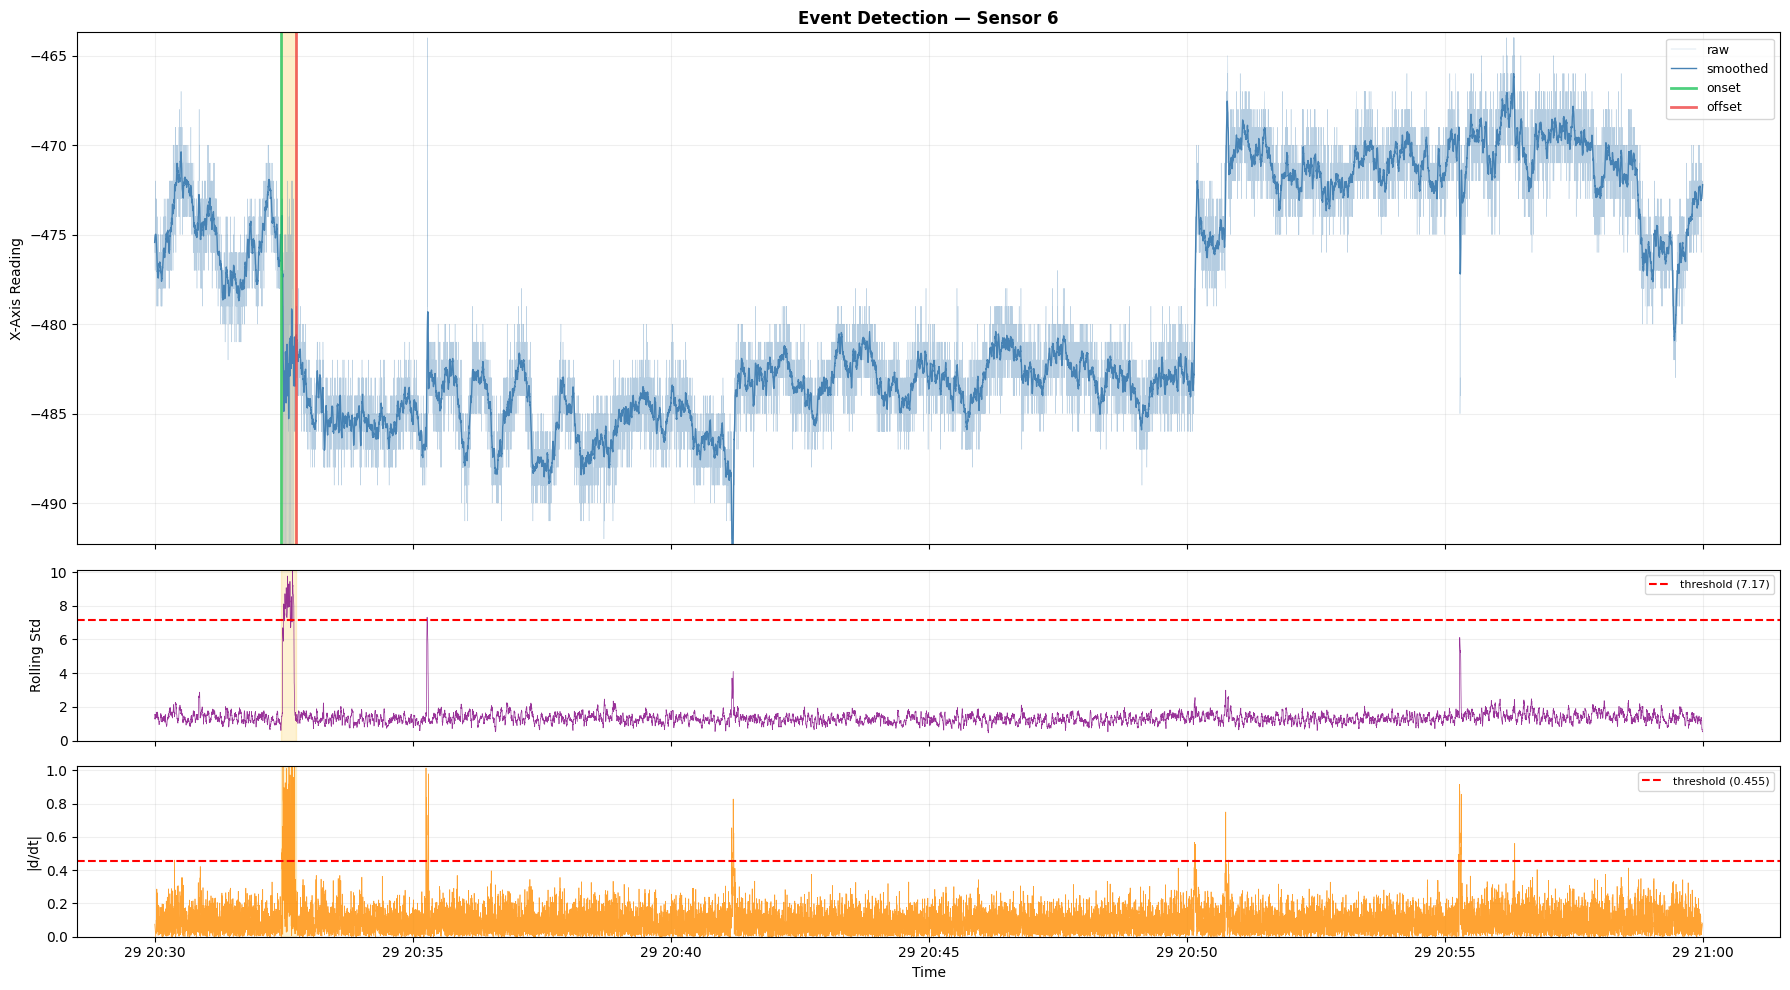

In [132]:
# Visualize: learned thresholds detection
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1, 1]})

# Top: signal + events — zoom y-axis to data range
ax = axes[0]
ax.plot(ts, raw, lw=0.3, color="steelblue", alpha=0.4, label="raw")
ax.plot(ts, smooth, lw=1, color="steelblue", label="smoothed")

for i, (s, e) in enumerate(events_l):
    e_clip = min(e, len(ts) - 1)
    ax.axvspan(ts[s], ts[e_clip], color="#fbbf24", alpha=0.25)
    ax.axvline(ts[s], color="#22c55e", lw=2, alpha=0.8,
               label="onset" if i == 0 else None)
    ax.axvline(ts[e_clip], color="#ef4444", lw=2, alpha=0.8,
               label="offset" if i == 0 else None)

# Overlay ground truth labels
data_start = pd.Timestamp(ts[0])
data_end = pd.Timestamp(ts[-1])
df_gt = df_sensor_labels.copy()
if data_start.tzinfo is None and df_gt["start_time"].dt.tz is not None:
    df_gt["start_time"] = df_gt["start_time"].dt.tz_localize(None)
    df_gt["end_time"] = df_gt["end_time"].dt.tz_localize(None)
elif data_start.tzinfo is not None and df_gt["start_time"].dt.tz is None:
    df_gt["start_time"] = df_gt["start_time"].dt.tz_localize(data_start.tzinfo)
    df_gt["end_time"] = df_gt["end_time"].dt.tz_localize(data_start.tzinfo)
gt_in_window = df_gt[(df_gt["end_time"] >= data_start) & (df_gt["start_time"] <= data_end)]
for idx, row in gt_in_window.iterrows():
    ax.axvspan(row["start_time"], row["end_time"], color="#8b5cf6", alpha=0.15,
               label="ground truth" if idx == gt_in_window.index[0] else None)

# Zoom y to p1-p99 range with some padding
y_lo, y_hi = np.percentile(raw, [1, 99])
y_pad = (y_hi - y_lo) * 0.15
ax.set_ylim(y_lo - y_pad, y_hi + y_pad)

ax.set_ylabel("X-Axis Reading")
ax.set_title(f"Event Detection — Sensor {SENSOR_ID}", fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.2)

# Middle: rolling std — clip y to useful range
ax = axes[1]
ax.plot(ts, roll_std, lw=0.5, color="purple", alpha=0.8)
ax.axhline(learned_std_thresh, color="red", ls="--", lw=1.5,
           label=f"threshold ({learned_std_thresh:.2f})")
for s, e in events_l:
    ax.axvspan(ts[s], ts[min(e, len(ts)-1)], color="#fbbf24", alpha=0.2)
ax.set_ylim(0, min(np.percentile(roll_std, 99.5) * 2, roll_std.max()))
ax.set_ylabel("Rolling Std")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# Bottom: |derivative| — clip y to useful range
ax = axes[2]
ax.plot(ts[1:], deriv, lw=0.5, color="darkorange", alpha=0.8)
ax.axhline(learned_deriv_thresh, color="red", ls="--", lw=1.5,
           label=f"threshold ({learned_deriv_thresh:.3f})")
for s, e in events_l:
    ax.axvspan(ts[s], ts[min(e, len(ts)-1)], color="#fbbf24", alpha=0.2)
ax.set_ylim(0, min(np.percentile(deriv, 99.5) * 2, deriv.max()))
ax.set_ylabel("|d/dt|")
ax.set_xlabel("Time")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Zoomed-In View of Each Detected Event

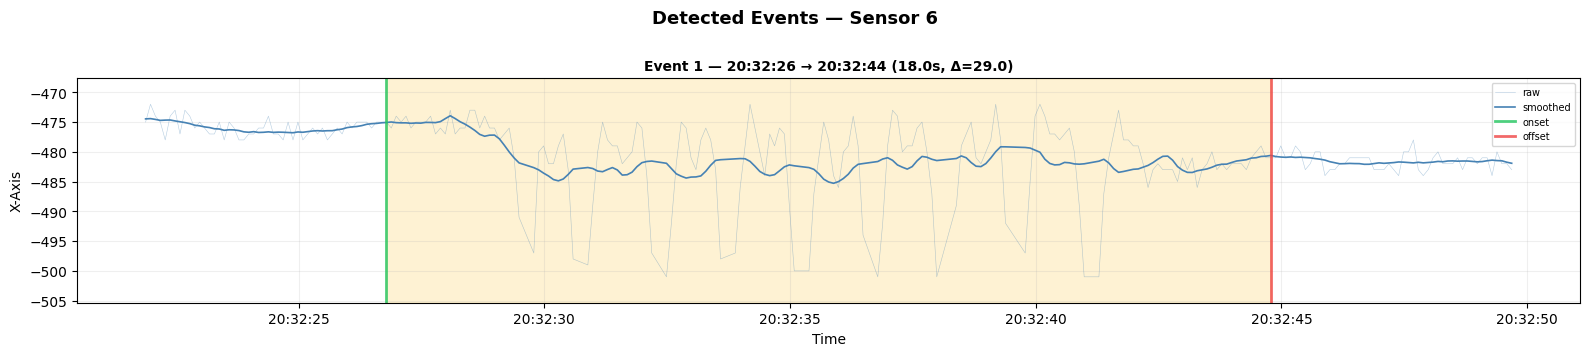

In [133]:
# Zoom into each detected event with some context
CONTEXT_S = 5  # seconds of context before/after the event
ctx_samples = int(CONTEXT_S * samples_per_sec)

n_ev = len(events_l)
if n_ev > 0:
    fig, axes = plt.subplots(n_ev, 1, figsize=(16, 3.5 * n_ev), squeeze=False)
    
    for i, (s, e) in enumerate(events_l):
        ax = axes[i, 0]
        lo = max(0, s - ctx_samples)
        hi = min(len(raw), e + ctx_samples + 1)
        
        # Raw + smoothed
        ax.plot(ts[lo:hi], raw[lo:hi], lw=0.4, color="steelblue", alpha=0.4, label="raw")
        ax.plot(ts[lo:hi], smooth[lo:hi], lw=1.2, color="steelblue", label="smoothed")
        
        # Event region
        ax.axvspan(ts[s], ts[min(e, len(ts)-1)], color="#fbbf24", alpha=0.2)
        ax.axvline(ts[s], color="#22c55e", lw=2, alpha=0.8, label="onset")
        ax.axvline(ts[min(e, len(ts)-1)], color="#ef4444", lw=2, alpha=0.8, label="offset")
        
        # Stats
        t0 = pd.Timestamp(ts[s])
        t1 = pd.Timestamp(ts[min(e, len(ts)-1)])
        dur = (t1 - t0).total_seconds()
        seg_vals = raw[s:e+1]
        
        ax.set_title(f"Event {i+1} — {t0.strftime('%H:%M:%S')} → {t1.strftime('%H:%M:%S')} "
                     f"({dur:.1f}s, Δ={seg_vals.max()-seg_vals.min():.1f})",
                     fontsize=10, fontweight="bold")
        ax.set_ylabel("X-Axis")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.2)
        
        # Zoom y to this segment's range
        seg_all = raw[lo:hi]
        y_lo, y_hi = seg_all.min(), seg_all.max()
        y_pad = (y_hi - y_lo) * 0.15
        ax.set_ylim(y_lo - y_pad, y_hi + y_pad)
    
    axes[-1, 0].set_xlabel("Time")
    plt.suptitle(f"Detected Events — Sensor {SENSOR_ID}", fontweight="bold", fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()
else:
    print("No events detected.")

## 6. Precision / Recall Evaluation

For each labeled segment, run the detector and measure:
- **Recall**: did we detect the event? (predicted onset within tolerance of true onset)
- **Precision**: of all detected events, how many match a real label?
- **Onset error**: how far off is the predicted onset from the true onset?

In [134]:
# Run the detector on each labeled segment individually and measure accuracy
ONSET_TOLERANCE_S = 3.0  # a detection counts as correct if onset is within this many seconds

results = []
for seg in segments:
    d = seg["df"]
    x = d["x"].values.astype(float)
    t = d["created_at"].values

    if len(x) < 20:
        continue

    # Apply same detection pipeline
    win = min(SMOOTH_WINDOW, len(x) // 2 * 2 + 1)
    if win < 3:
        continue
    sm = savgol_filter(x, window_length=win, polyorder=SMOOTH_POLY)
    dr = np.abs(np.diff(sm))
    rs = pd.Series(x).rolling(ROLLING_STD_WIN, center=True, min_periods=3).std().fillna(0).values

    is_vol = rs > learned_std_thresh
    is_edg = np.zeros(len(sm), dtype=bool)
    is_edg[1:] = dr > learned_deriv_thresh

    # Find events
    is_ev = np.zeros(len(sm), dtype=bool)
    in_ev = False
    for i in range(len(sm)):
        if not in_ev:
            if is_vol[i] and np.any(is_edg[max(0, i-5):min(len(is_edg), i+5)]):
                in_ev = True
                is_ev[i] = True
        else:
            if is_vol[i]:
                is_ev[i] = True
            else:
                in_ev = False

    # Extract first detected onset
    detected_onset_idx = None
    for i in range(len(is_ev)):
        if is_ev[i]:
            detected_onset_idx = i
            break

    # True onset index
    true_onset_idx = np.argmin(np.abs(t - np.datetime64(seg["label_start"])))
    true_onset_time = pd.Timestamp(t[true_onset_idx])

    if detected_onset_idx is not None:
        det_onset_time = pd.Timestamp(t[detected_onset_idx])
        error_s = (det_onset_time - true_onset_time).total_seconds()
        hit = abs(error_s) <= ONSET_TOLERANCE_S
    else:
        det_onset_time = None
        error_s = None
        hit = False

    results.append({
        "label_id": seg["label_id"],
        "fixture_type": seg["fixture_type"],
        "fixture_name": seg["fixture_name"],
        "true_onset": true_onset_time,
        "detected_onset": det_onset_time,
        "error_s": error_s,
        "hit": hit,
    })

df_results = pd.DataFrame(results)

n_total = len(df_results)
n_hits = df_results["hit"].sum()
recall = n_hits / n_total if n_total > 0 else 0

errors = df_results.loc[df_results["hit"], "error_s"]
mean_error = errors.mean() if len(errors) > 0 else float("nan")
median_error = errors.median() if len(errors) > 0 else float("nan")

print(f"=== Evaluation ({ONSET_TOLERANCE_S}s tolerance) ===")
print(f"  Labels tested:    {n_total}")
print(f"  Detected (hit):   {n_hits}")
print(f"  Missed:           {n_total - n_hits}")
print(f"  Recall:           {recall:.1%}")
print(f"  Mean onset error: {mean_error:+.2f}s")
print(f"  Median onset error: {median_error:+.2f}s")

print(f"\n--- Per fixture type ---")
for ft, grp in df_results.groupby("fixture_type"):
    r = grp["hit"].mean()
    errs = grp.loc[grp["hit"], "error_s"]
    me = errs.mean() if len(errs) > 0 else float("nan")
    print(f"  {ft}: {grp['hit'].sum()}/{len(grp)} detected (recall={r:.0%}, mean error={me:+.2f}s)")

missed = df_results[~df_results["hit"]]
if len(missed) > 0:
    print(f"\n--- Missed events ---")
    for _, row in missed.iterrows():
        det = row["detected_onset"] if row["detected_onset"] is not None else "NOT DETECTED"
        print(f"  Label {row['label_id']} ({row['fixture_type']}): true={row['true_onset']}, detected={det}, error={row['error_s']}")

=== Evaluation (3.0s tolerance) ===
  Labels tested:    14
  Detected (hit):   14
  Missed:           0
  Recall:           100.0%
  Mean onset error: +1.96s
  Median onset error: +2.25s

--- Per fixture type ---
  sink: 4/4 detected (recall=100%, mean error=+1.03s)
  toilet: 10/10 detected (recall=100%, mean error=+2.33s)


/var/folders/m5/56bf4mwd3wn96np9dzczw3xr0000gn/T/ipykernel_14009/1286511231.py:47: UserWarning: no explicit representation of timezones available for np.datetime64
  true_onset_idx = np.argmin(np.abs(t - np.datetime64(seg["label_start"])))
